# Clustering

This is part of the EDA to understand who is happy and who is not.

In [231]:
from c08_farming_exit import config
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [232]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

In [233]:
#Feature List
X = [
    "personal_id",
    "female",
    "age",
    "years_of_schooling",
    "land_size_cropland_acres",

    "farm_empl_last_12_months",
    "empl_type",

    "hh_optimism_index",
    "worry_about_job_loss_or_economic_livelihood",
    "life_satisfaction",

    "aspiration_continue_farming",
    "child_aspiration_continue_farming",

    "main_decision_maker",
]

df = df[X]

In [234]:
#Are you the main decision maker? Create dummy with 1 0 
df['main_decision_maker'] = (df['personal_id'] == df['main_decision_maker']).astype(int)
df = df.drop(columns=['personal_id'])

In [235]:
# Check all dtypes
df.dtypes

# Split into numerical and categorical
numerical_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['female', 'age', 'years_of_schooling', 'land_size_cropland_acres', 'farm_empl_last_12_months', 'hh_optimism_index', 'worry_about_job_loss_or_economic_livelihood', 'life_satisfaction', 'child_aspiration_continue_farming', 'main_decision_maker']
Categorical: ['empl_type', 'aspiration_continue_farming']


In [236]:
missing = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().mul(100).round(1),
}).sort_values("pct_missing", ascending=False)
missing


,dtype,n_missing,pct_missing
empl_type,object,2205,74.1
child_aspiration_continue_farming,float64,997,33.5
farm_empl_last_12_months,float64,864,29.1
life_satisfaction,float64,153,5.1
aspiration_continue_farming,object,153,5.1
land_size_cropland_acres,float64,150,5.0
female,int64,0,0.0
age,float64,0,0.0
years_of_schooling,float64,0,0.0
hh_optimism_index,float64,1,0.0


In [237]:
# Numerical outlier treatment: clip values outside the 1%/99% quantiles, ignoring NaNs
for col in numerical_cols:
    lower = df[col].quantile(0.01)   # quantile() ignores NaNs by default
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

In [238]:
#Fill numerical missings
# Fill farm_empl_last_12_months missings with 0
df["farm_empl_last_12_months"] = df["farm_empl_last_12_months"].fillna(0)

# Fill life_satisfaction and land_size_cropland_acres missings with their column mean
for col in ["child_aspiration_continue_farming", "life_satisfaction", "land_size_cropland_acres", "hh_optimism_index", "worry_about_job_loss_or_economic_livelihood"]:
    df[col] = df[col].fillna(df[col].mean())

In [239]:
# Fill categorical missings
df[categorical_cols] = df[categorical_cols].fillna("missing")

In [240]:
# One-Hot Encode Categorical Features
# drop_first=True reduces multi-collinearity for binary/dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

In [241]:
# Scale all features for K-Means and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

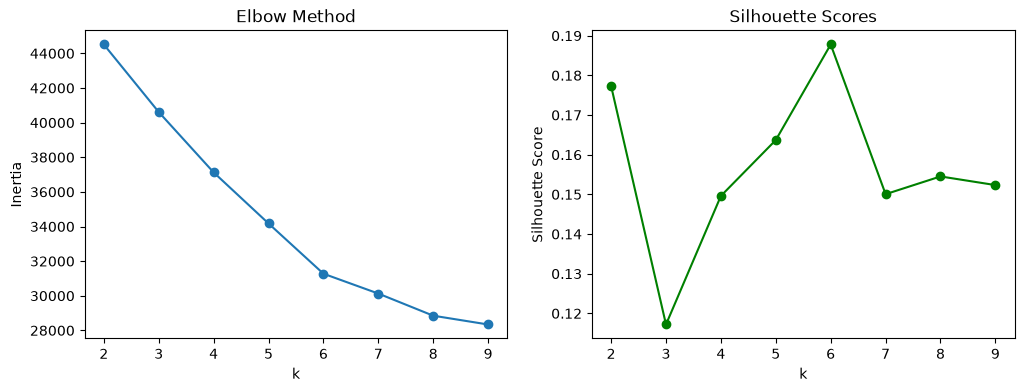

In [242]:
# Elbow Method & Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Evaluation Metrics
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_range, silhouette_scores, marker="o", color="green")
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette Score")
plt.show()


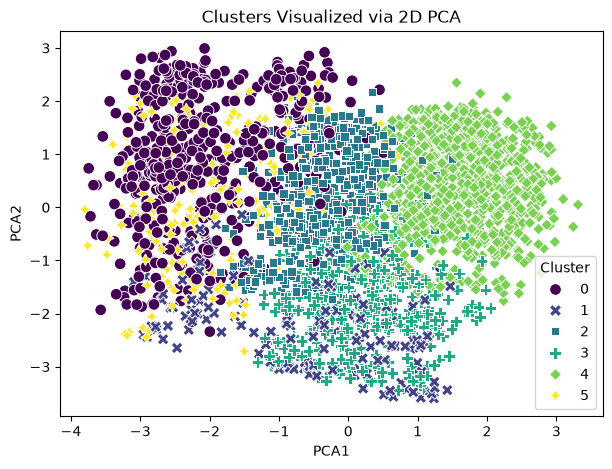

In [243]:
# Fit K-Means with optimal k (e.g., k=4)
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# 6. PCA to 2D & Plot Scatter Plot
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df["PCA1"] = pca_coords[:, 0]
df["PCA2"] = pca_coords[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    style="Cluster",
    s=70,
)
plt.title("Clusters Visualized via 2D PCA")
plt.show()

In [244]:
# Calculate Mean/Profile Characteristics Per Cluster
# Cluster size
cluster_size = df.groupby("Cluster").size().rename("cluster_size")

# Numerical averages
cluster_means = df.groupby("Cluster")[numerical_cols].mean()

# Categorical distributions (percentages/modes per cluster)
cat_profile = df.groupby("Cluster")[categorical_cols].agg(
    lambda x: x.mode()[0]
)

# Combine summary table
summary_df = pd.concat([cluster_size, cluster_means, cat_profile], axis=1)

print("\n--- Cluster Summary Profile ---")
print(summary_df)



--- Cluster Summary Profile ---
         cluster_size    female        age  years_of_schooling  \
Cluster                                                          
0                 479  0.532359  42.896576            7.584551   
1                 153  0.562092  51.484379            6.424837   
2                 648  0.589506  43.748210            6.662037   
3                 407  0.663391  48.588821            4.977887   
4                1045  0.537799  53.596536            5.533014   
5                 242  0.462810  41.696116            8.776860   

         land_size_cropland_acres  farm_empl_last_12_months  \
Cluster                                                       
0                        4.315799                  0.597077   
1                        5.416462                  0.274510   
2                        4.726956                  0.655864   
3                        2.578011                  0.346437   
4                        5.436034                  0.715789 